## FIGURE 3 for WUS CMIP6 WARMING PAPER

In [1]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
os.environ['ESMFMKFILE'] = '/home/tessj/miniconda3/envs/xarrayxesmf/lib/esmf.mk'
import xesmf as xe
import numpy as np
#import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns
import xskillscore as xsc
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

import statsmodels.api as sm
import json

In [2]:
modmembers_geq3_tas = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_tas_total.json', 'r') as file:
        modmembers_geq3_tas = json.load(file)
        
modmembers_geq3_lwd = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_lwd_total.json', 'r') as file:
        modmembers_geq3_lwd = json.load(file)

modmembers_geq3_huss = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_huss_total.json', 'r') as file:
        modmembers_geq3_huss = json.load(file)

In [3]:
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_pl_total.json', 'r') as file:
        modmembers_all = json.load(file)
        

In [4]:
# make land mask from ERA5 and CMIP6 regridded data
tas_test = xr.open_dataset(f'/d3/tessj/data/CMIP6/for_tess/ACCESS-ESM1-5/tas_Amon_ACCESS-ESM1-5_historical_r3i1p1f1_18500101-20141231_regrid.nc').sel(time=slice('1941-01-01', '2014-12-31'))
landmask = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.interp_like(tas_test)
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [5]:
wusbox = [-125, -102, 32,  49]

In [6]:
weights = np.cos(np.deg2rad(landmask.lat))

In [9]:
datetimes_np64 = np.arange('1941-01', '2025-01', dtype='datetime64[M]')
datetimes_np64 = datetimes_np64.astype('datetime64[ns]')

### Open GISS and Berkeley observational data

In [10]:
gisstemp = xr.open_dataset('/home/tessj/wus_temp_trends/gistemp250_GHCNv4.nc').sel(time=slice('1941-01-01', '2024-12-31')).assign_coords({'time':datetimes_np64}).drop('time_bnds')

In [11]:
gisstemp_wus = gisstemp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
gisstemp_weights = np.cos(np.deg2rad(gisstemp.lat))

gisstemp_wus_avg = gisstemp_wus.weighted(gisstemp_weights).mean(['lon','lat'])
gisstemp_globland_avg = gisstemp.weighted(gisstemp_weights).mean(['lon','lat'])

In [12]:
gisstemp_wus_avg_szn = {}
gisstemp_globland_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_szn[szn] = gisstemp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    gisstemp_globland_avg_szn[szn] = gisstemp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [13]:
berk_temp = xr.open_dataset('/home/tessj/wus_temp_trends/Complete_TAVG_LatLong1.nc', decode_times=True).isel(time=slice(12*191,3300)).assign_coords({'time':gisstemp.time}).rename({'latitude':'lat', 'longitude':'lon'})

In [14]:
berk_temp_wus = berk_temp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
berk_temp_na = berk_temp.sel(lon=slice(wusbox[0],-90), lat=slice(20,60))

berk_temp_weights = np.cos(np.deg2rad(berk_temp.lat))

berk_temp_wus_avg = berk_temp_wus.weighted(berk_temp_weights).mean(['lon','lat'])
berk_temp_globland_avg = berk_temp.weighted(berk_temp_weights).mean(['lon','lat'])

In [15]:
berk_temp_wus_avg_trend = berk_temp_wus_avg.sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
berk_temp_globland_avg_trend = berk_temp_globland_avg.sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [16]:
berk_temp_wus_avg_szn = {}
berk_temp_globland_avg_szn = {}
berk_temp_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_szn[szn] = berk_temp_na.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_wus_avg_szn[szn] = berk_temp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_globland_avg_szn[szn] = berk_temp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [17]:
berk_temp_wus_avg_trend_szn = {}
berk_temp_globland_avg_trend_szn = {}
berk_temp_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_globland_avg_trend_szn[szn] = berk_temp_globland_avg_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_wus_trend_szn[szn] = berk_temp_wus_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [18]:
berk_temp_wus_trend_szn_p = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):

    berk_temp_wus_trend_szn_p[szn] = xsc.pearson_r_p_value(berk_temp_wus_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').year,
                                                           berk_temp_wus_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time'), dim='year')

/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_de

In [19]:
berk_temp_wus_avg_trend_80_14_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_80_14_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2014-12-31')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


### Open CMIP6 model averages

In [20]:
ds_tas_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_avgs.nc')
ds_tas_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_na.nc')

In [21]:
ds_lwd_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_avgs.nc')
ds_lwd_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_na.nc')

In [23]:
ds_huss_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_huss_avgs.nc')
ds_huss_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_huss_na.nc')

In [24]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim


In [25]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim

ds_tas_avg_m_clim = ds_tas_avg.groupby('time.month').mean('time')
ds_tas_avg_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_m_clim

In [26]:
ds_tas_wus_51_80_m_clim = ds_tas_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_wus_51_80_m_anom = ds_tas_wus.groupby('time.month') - ds_tas_wus_51_80_m_clim

In [27]:
ds_tas_avg_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_szn[szn] = ds_tas_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [28]:
ds_tas_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_trend_szn[szn] = ds_tas_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [29]:
ds_lwd_wus_51_80_m_clim = ds_lwd_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_wus_51_80_m_anom = ds_lwd_wus.groupby('time.month') - ds_lwd_wus_51_80_m_clim

In [31]:
ds_huss_wus_51_80_m_clim = ds_huss_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_huss_wus_51_80_m_anom = ds_huss_wus.groupby('time.month') - ds_huss_wus_51_80_m_clim

In [32]:
ds_lwd_wus_51_80_m_anom_szn = {}
ds_huss_wus_51_80_m_anom_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_wus_51_80_m_anom_szn[szn] = ds_lwd_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    ds_huss_wus_51_80_m_anom_szn[szn] = ds_huss_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [33]:
ds_lwd_wus_51_80_m_anom_trend_szn = {}
ds_huss_wus_51_80_m_anom_trend_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_wus_51_80_m_anom_trend_szn[szn] = ds_lwd_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_huss_wus_51_80_m_anom_trend_szn[szn] = ds_huss_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [34]:
ds_tas_wus_51_80_m_anom_szn = {}
ds_tas_wus_51_80_m_anom_trend_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_wus_51_80_m_anom_szn[szn] = ds_tas_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    ds_tas_wus_51_80_m_anom_trend_szn[szn] = ds_tas_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [35]:
ds_lwd_avg_51_80_m_clim = ds_lwd_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_avg_51_80_m_anom = ds_lwd_avg.groupby('time.month') - ds_lwd_avg_51_80_m_clim

ds_huss_avg_51_80_m_clim = ds_huss_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_huss_avg_51_80_m_anom = ds_huss_avg.groupby('time.month') - ds_huss_avg_51_80_m_clim

In [36]:
ds_lwd_avg_51_80_m_anom_szn = {}
ds_huss_avg_51_80_m_anom_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_szn[szn] = ds_lwd_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_huss_avg_51_80_m_anom_szn[szn] = ds_huss_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    


In [37]:
ds_lwd_avg_51_80_m_anom_trend_szn = {}
ds_huss_avg_51_80_m_anom_trend_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_huss_avg_51_80_m_anom_trend_szn[szn] = ds_huss_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Open ERA5 data

In [38]:
era5_sl_wus= xr.open_dataset('/home/tessj/wus_temp_trends/era5_slvars_1940_2024_na.nc')[['tp', 'z','e', 't2m','d2m','sp']].load()

In [39]:
era5_lwd = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msdwlwrf_1940_2025.nc').load()

In [40]:
era5_lwd = fix_coords_lon(era5_lwd).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])

In [41]:
#era5_sl_wus = era5_sl_wus.drop('avg_sdlwrf').isel(time=slice(None,None,2))

In [42]:
era5_lwd = era5_lwd.assign_coords(time=era5_sl_wus.time)

In [43]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_lwd.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [44]:
# calculate qs
es0 = 6.11 #mb
c1 = 17.67 
T0 =  273.15 #K
#es_a = es0*np.exp(c1*(ds.t2m - T0)/(ds.t2m - T0 + 243.5))
ea = es0*np.exp(c1*(era5_sl_wus.d2m - T0)/(era5_sl_wus.d2m - T0 + 243.5))
#VPD = es_a - ea
#VPD.attrs['units'] = 'mbar'
#es_a.attrs['units'] = 'mbar'
ea.attrs['units'] = 'mbar'

#ds['VPD'] = VPD
#ds['es_a'] = es_a
#ds['ea'] = ea

# calculate surface specific humidity (q) and add to dataset
# https://cran.r-project.org/web/packages/humidity/vignettes/humidity-measures.html
# q \approx 0.622*e / (p−0.378e)
MwMd = 0.622
era5_sl_wus['qs'] = (MwMd*ea)/((era5_sl_wus.sp/100) - 0.378*ea)
era5_sl_wus['qs'].attrs['units'] = 'kg/kg'

In [48]:
era5_weights = np.cos(np.deg2rad(era5_sl_wus.lat))
landmask = fix_coords_lon(xr.open_dataarray('/net/kage/d4/naomi/DataCatalog/ERA5/monthly/single_level/y1979-2020/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [49]:
era5_sl_wus_51_80_m_clim = era5_sl_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
era5_sl_wus_51_80_m_anom = era5_sl_wus.groupby('time.month') - era5_sl_wus_51_80_m_clim

In [50]:
era5_sl_wus_avg_51_80_m_clim = era5_sl_wus_51_80_m_clim.where(landmask==landmask).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).weighted(era5_weights).mean(['lon', 'lat'])


In [51]:
era5_sl_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_szn[szn] = era5_sl_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [52]:
era5_sl_wus_51_80_m_trend = era5_sl_wus_51_80_m_anom.sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
era5_sl_wus_51_80_m_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_trend_szn[szn] = era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [53]:
era5_sl_wus_51_80_m_trend_szn_p = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_trend_szn_p[szn] = xsc.pearson_r_p_value(era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time'),
        era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').year, dim='year')

/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/tessj/miniconda3/envs/cmip6-tess/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den


In [54]:
era5_sl_wus_51_80_m_anom_avg = era5_sl_wus_51_80_m_anom.where(landmask==landmask).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).weighted(era5_weights).mean(['lon', 'lat'])

In [55]:
era5_sl_wus_51_80_m_anom_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_avg_szn[szn] = era5_sl_wus_51_80_m_anom_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [56]:
era5_sl_wus_51_80_m_anom_avg_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_avg_trend_szn[szn] = era5_sl_wus_51_80_m_anom_avg_szn[szn].sel(time=slice('1980-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### fit regression model based on modeled temperature and surface q trends

In [57]:
commonmodels = list(set(ds_huss_avg_51_80_m_anom_trend_szn['JFM'].model.values) & set(ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].model.values))

In [58]:
# observed trends
da_temp_obs = 45*berk_temp_wus_trend_szn['JFM'].temperature_polyfit_coefficients
da_lwd_obs = 45*era5_sl_wus_51_80_m_trend_szn['JFM'].avg_sdlwrf_polyfit_coefficients
da_q_obs = 45*1000*era5_sl_wus_51_80_m_trend_szn['JFM'].qs_polyfit_coefficients

da_temp_obs_p = xr.zeros_like(berk_temp_wus_trend_szn['JFM']).temperature_polyfit_coefficients + berk_temp_wus_trend_szn_p['JFM'].temperature
da_lwd_obs_p = era5_sl_wus_51_80_m_trend_szn_p['JFM'].avg_sdlwrf
da_q_obs_p = era5_sl_wus_51_80_m_trend_szn_p['JFM'].qs

In [59]:
# model trends 
da_temp = 45*ds_tas_wus_51_80_m_anom_trend_szn['JFM'].tas_polyfit_coefficients.sel(model=commonmodels)
da_lwd = 45*ds_lwd_wus_51_80_m_anom_trend_szn['JFM'].lwd_polyfit_coefficients.sel(model=commonmodels)
da_q = 45*1000*ds_huss_wus_51_80_m_anom_trend_szn['JFM'].huss_polyfit_coefficients.sel(model=commonmodels)



In [60]:
# function to fit humidity trends based on temperature trends
def fit_temp_only(q, temp):

    mask = np.isfinite(q) & np.isfinite(temp)

    if mask.sum() < 3:
        return np.full(4, np.nan)

    y = q[mask]

    X = sm.add_constant(temp[mask])

    fit = sm.OLS(y, X).fit()

    return np.array([
        fit.params[0],      # intercept
        fit.params[1],      # beta_temp
        fit.rsquared,
        fit.pvalues[1],     # p_temp
    ])

results_temp = xr.apply_ufunc(
    fit_temp_only,
    da_q,
    da_temp,
    input_core_dims=[["model"], ["model"]],
    output_core_dims=[["parameter"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    output_sizes={"parameter": 4},
)

results_temp = results_temp.assign_coords(
    parameter=[
        "intercept",
        "beta_temp",
        "r2",
        "p_temp",
    ]
)

r2_temp_only = results_temp.sel(parameter="r2")
p_temp_only = results_temp.sel(parameter="p_temp")

/tmp/ipykernel_30786/269405392.py:22: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  results_temp = xr.apply_ufunc(


In [61]:
# calculate correlations
corr_t_q = xsc.pearson_r(da_temp, da_q, dim='model')
corr_p_t_q = xsc.pearson_r_p_value(da_temp, da_q, dim='model')
corr_p_lwd_q = xsc.pearson_r_p_value(da_lwd, da_q, dim='model')
corr_t_lwd = xsc.pearson_r(da_temp, da_lwd, dim='model')

In [63]:
# get intercept
intercept_temp = results_temp.sel(parameter="intercept")
beta_temp_only = results_temp.sel(parameter="beta_temp")


# predict humidity trend based on model relationship + observed temperature trends
q_pred_temp = (
    intercept_temp
    + beta_temp_only * da_temp_obs)

### plot figure 3

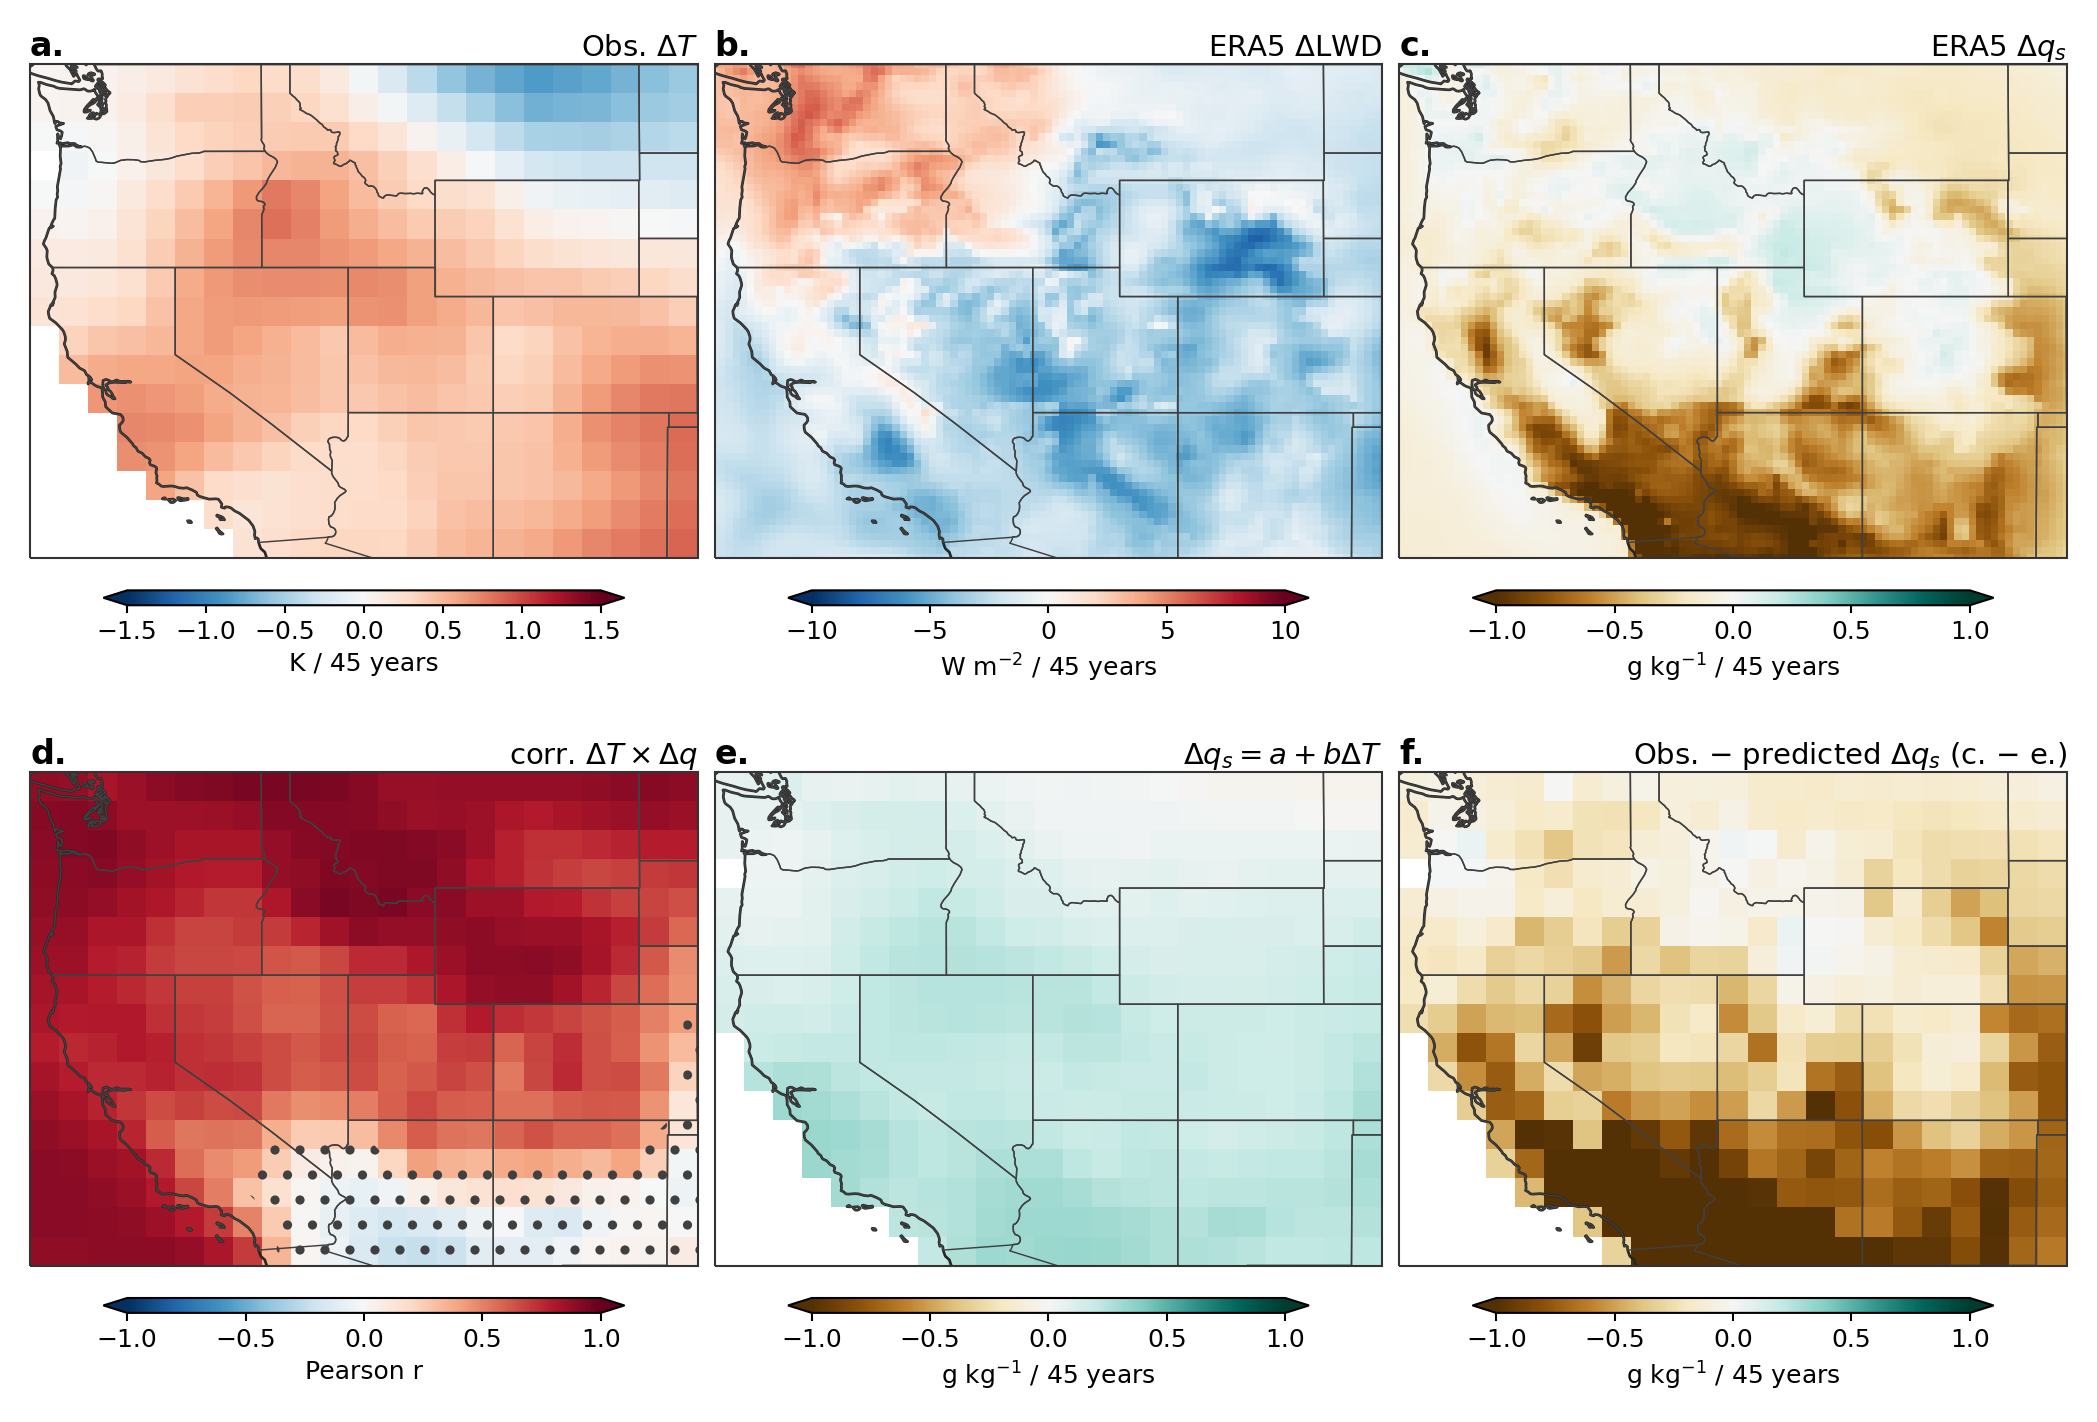

In [64]:
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize": 6, "ytick.labelsize": 6})
extent = [-125, -102, 32, 49]

fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.65), dpi=300, subplot_kw={"projection": ccrs.PlateCarree()})

def style_map(ax, panel, title):
    ax.set_title("")
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.65, color="0.15")
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor="0.25")
    ax.spines["geo"].set_linewidth(0.5)
    ax.spines["geo"].set_edgecolor("0.2")
    ax.set_title(panel, loc="left", fontsize=8, fontweight="bold", pad=2)
    ax.set_title(title, loc="right", fontsize=7, pad=2)

def add_cbar(fig, ax, im, label):
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.045, pad=0.055, aspect=35, shrink=0.78, extend="both")
    cbar.set_label(label, fontsize=6, labelpad=2)
    cbar.ax.tick_params(labelsize=6, length=2, width=0.5, pad=1.5)
    cbar.outline.set_linewidth(0.5)
    return cbar

ax = axes[0, 0]
im = da_temp_obs.plot(ax=ax, cmap="RdBu_r", vmin=-1.5, vmax=1.5, extend="both", transform=ccrs.PlateCarree(), add_colorbar=False)
#cs = da_temp_obs_p.where(da_temp_obs_p >= 0.05).sel(month_number=1).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=[0, 1], hatches=[".."], colors="none", add_colorbar=False)
style_map(ax, "a.", r"Obs. $\Delta T$"); add_cbar(fig, ax, im, r"K / 45 years")

ax = axes[0, 1]; im = da_lwd_obs.plot(ax=ax, cmap="RdBu_r", vmin=-10, vmax=10, extend="both", transform=ccrs.PlateCarree(), add_colorbar=False)
#cs = da_lwd_obs_p.where(da_lwd_obs_p >= 0.05).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=[0, 1], hatches=[".."], colors="none", add_colorbar=False)
style_map(ax, "b.", r"ERA5 $\Delta$LWD"); add_cbar(fig, ax, im, r"W m$^{-2}$ / 45 years")

ax = axes[0, 2]; im = da_q_obs.plot(ax=ax, cmap="BrBG", vmin=-1, vmax=1, extend="both", transform=ccrs.PlateCarree(), add_colorbar=False)
#cs = da_q_obs_p.where(da_q_obs_p >= 0.05).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=[0, 1], hatches=[".."], colors="none", add_colorbar=False)

style_map(ax, "c.", r"ERA5 $\Delta q_s$"); add_cbar(fig, ax, im, r"g kg$^{-1}$ / 45 years")

ax = axes[1, 0]; im = corr_t_q.plot(ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, extend="both", transform=ccrs.PlateCarree(), add_colorbar=False)
sig = corr_p_t_q.where(corr_p_t_q >= 0.05)
cs = sig.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=[0, 1], hatches=[".."], colors="none", add_colorbar=False)
for collection in cs.collections: collection.set_edgecolor("0.25"); collection.set_linewidth(0)
style_map(ax, "d.", r"corr. $\Delta T \times \Delta q$"); add_cbar(fig, ax, im, "Pearson r")

ax = axes[1, 1]; im = q_pred_temp.plot(ax=ax, cmap="BrBG", vmin=-1, vmax=1, extend="both", transform=ccrs.PlateCarree(), add_colorbar=False)
style_map(ax, "e.", r"$\Delta q_s = a + b\Delta T$"); add_cbar(fig, ax, im, r"g kg$^{-1}$ / 45 years")

ax = axes[1, 2]; q_residual = 45 * 1000 * era5_sl_wus_51_80_m_trend_szn["JFM"].qs_polyfit_coefficients - q_pred_temp
im = q_residual.plot(ax=ax, cmap="BrBG", vmin=-1, vmax=1, extend="both", transform=ccrs.PlateCarree(), add_colorbar=False)
style_map(ax, "f.", r"Obs. $-$ predicted $\Delta q_s$ (c. $-$ e.)"); add_cbar(fig, ax, im, r"g kg$^{-1}$ / 45 years")

fig.subplots_adjust(left=0.015, right=0.985, bottom=0.055, top=0.985, wspace=0.025, hspace=0.20)
plt.show()
